In [1]:
from typing import Dict, List, Tuple


from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    per_target_consis_result_type,
    per_target_performance_result_type,
)

INFO: P [MainThread] 2026-02-25 16:51:19,084 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NA_UNet_source_models = {
    "PNAS": "p_model_NA1",
    "Ovules": "ov_model_NA1",
}
Res_source_models = {
    "FlyWing": "fw_model_Res2",
    "Ovules": "ov_model_Res1",
    "PNAS": "p_model_Res1",
}

Unetr_source_models = {
    "FlyWing": "fw_model_Unetr2",
    "Ovules": "ov_model_Unetr1",
    "PNAS": "p_model_Unetr1",
}
Unet_source_models={
    "FlyWing": "fw_model_Unet2",
    "Ovules": "ov_model_UNet1",
    "PNAS": "p_model_UNet1",
}
consis_keys={
    "FlyWing": "AdaRandError_consis",
    "Ovules": "AdaRandError_consis",
    "PNAS": "AdaRandError_consis",
}
# consis_keys={
#     "Ovules": "weighted_AdaRandError_consis",
# }
# consis_keys_bckg = {
#     "FlyWing": "AdaRandError_consis_bckg",
#     "Ovules": "AdaRandError_consis_bckg",
#     "PNAS": "AdaRandError_consis_bckg",
# }
result_folders={
    "FlyWing": "P_fullslice",
    "Ovules": "P_fullslice",
    "PNAS": "P_fullslice",
}

per_target_norms: Dict[str, List[Tuple[float,float]]] = {
    "FlyWing": [(5.0, 95.0)],
    "Ovules": [(5.0, 95.0)],
    "PNAS": [(5.0, 95.0)],
}

perf_key = "MAP_05_095"
approach="consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells"

In [3]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    #"gauss": ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"],
    #"gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-02"],
    #"gauss": ["a003-005", "a005-007", "a007-01", "a01-02"],
    #"gauss": ["a001-005", "a005-007", "a007-01", "a01-015", "a015-02", "a02-025", "a025-03"]
}
targets = ["FlyWing", "Ovules", "PNAS"]
#targets = ["FlyWing"]
#targets = ["FlyWing", "Ovules"]
#targets = ["Ovules"]
#source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
source_model_types = [Unet_source_models, NA_UNet_source_models,  Res_source_models]

In [4]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
sources = ["FlyWing", "Ovules", "PNAS"]
for i, target in enumerate(targets):
        
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        if "NA" in model_type["PNAS"]:
            sources = ["Ovules", "PNAS"]
        
        else:
            sources = ["FlyWing", "Ovules", "PNAS"]
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            #consis_postfix="median",
            consis_postfix=None,
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: FlyWing


100%|██████████| 1/1 [00:00<00:00, 198.78it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 217.13it/s]


Source: PNAS


...

100%|██████████| 1/1 [00:00<00:00, 357.66it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 344.50it/s]


Source: PNAS


100%|██████████| 1/1 [00:00<00:00, 346.87it/s]


In [5]:
per_target_forg_performance

{'FlyWing': {'fw_model_Unet2': {'norm_50_950': 0.6657333374023438},
  'ov_model_UNet1': {'norm_50_950': 0.38418108224868774},
  'p_model_UNet1': {'norm_50_950': 0.41681015491485596},
  'ov_model_NA1': {'norm_50_950': 0.004466201178729534},
  'p_model_NA1': {'norm_50_950': 0.4525538682937622},
  'fw_model_Res2': {'norm_50_950': 0.6304502487182617},
  'ov_model_Res1': {'norm_50_950': 0.03530129790306091},
  'p_model_Res1': {'norm_50_950': 0.5204195976257324}},
 'Ovules': {'fw_model_Unet2': {'norm_50_950': 0.20723387598991394},
  'ov_model_UNet1': {'norm_50_950': 0.37114906311035156},
  'p_model_UNet1': {'norm_50_950': 0.38671332597732544},
  'ov_model_NA1': {'norm_50_950': 0.41953617334365845},
  'p_model_NA1': {'norm_50_950': 0.3829978108406067},
  'fw_model_Res2': {'norm_50_950': 0.28687822818756104},
  'ov_model_Res1': {'norm_50_950': 0.4256826937198639},
  'p_model_Res1': {'norm_50_950': 0.38928115367889404}},
 'PNAS': {'fw_model_Unet2': {'norm_50_950': 0.501760721206665},
  'ov_mode

In [6]:
model_to_data_abbrevs = {
    "ov": "Ovules",
    "fw": "FlyWing",
    "p": "PNAS",
}
data_to_model_abbrevs = {v:k for k,v in model_to_data_abbrevs.items()}

In [7]:
per_target_source_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_source_performance[target] = {}
    for model, performance in per_model_performance.items():
        abbrev = model.split("_")[0]
        model_source = model_to_data_abbrevs[abbrev]
        if model_source == target:
            if isinstance(performance, dict):
                per_target_source_performance[target][model] = performance['norm_50_950']
            else:
                per_target_source_performance[target][model] = performance
        else:
            source_performance = per_target_forg_performance[model_source][model]
            if isinstance(source_performance, dict):
                per_target_source_performance[target][model] = source_performance['norm_50_950']
            else:
                per_target_source_performance[target][model] = source_performance

In [8]:
per_target_source_performance

{'FlyWing': {'fw_model_Unet2': 0.6657333374023438,
  'ov_model_UNet1': 0.37114906311035156,
  'p_model_UNet1': 0.6804121732711792,
  'ov_model_NA1': 0.41953617334365845,
  'p_model_NA1': 0.6776507496833801,
  'fw_model_Res2': 0.6304502487182617,
  'ov_model_Res1': 0.4256826937198639,
  'p_model_Res1': 0.6867726445198059},
 'Ovules': {'fw_model_Unet2': 0.6657333374023438,
  'ov_model_UNet1': 0.37114906311035156,
  'p_model_UNet1': 0.6804121732711792,
  'ov_model_NA1': 0.41953617334365845,
  'p_model_NA1': 0.6776507496833801,
  'fw_model_Res2': 0.6304502487182617,
  'ov_model_Res1': 0.4256826937198639,
  'p_model_Res1': 0.6867726445198059},
 'PNAS': {'fw_model_Unet2': 0.6657333374023438,
  'ov_model_UNet1': 0.37114906311035156,
  'p_model_UNet1': 0.6804121732711792,
  'ov_model_NA1': 0.41953617334365845,
  'p_model_NA1': 0.6776507496833801,
  'fw_model_Res2': 0.6304502487182617,
  'ov_model_Res1': 0.4256826937198639,
  'p_model_Res1': 0.6867726445198059}}

In [ ]:
import json
import os
from model_ranking.results import convert_numpy_types
from typing import Any

save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# for i, alpha in enumerate(selected_augmentations['gauss']):
#     per_target_consistency: Dict[str, Dict[str,float]] = {}
#     for target, per_model_consistency in per_target_forg_consistency.items():
#         per_target_consistency[target] = {}
#         for model, consistency in per_model_consistency.items():
#             per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

#     with open(os.path.join(save_path, f"transfer_self_supervised_Gauss_{alpha}_FORG_ARE_scores.json"), "w") as f:
#         results: Dict[str, Any] = {
#             "transfer_scores": convert_numpy_types(per_target_consistency),
#         }
#         json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"direct_source_performance_score_as_transfer_metric.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "transfer_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)


In [13]:
import json

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    avg_correlation_table,
)

In [10]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

Processing: Direct Source Performance
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


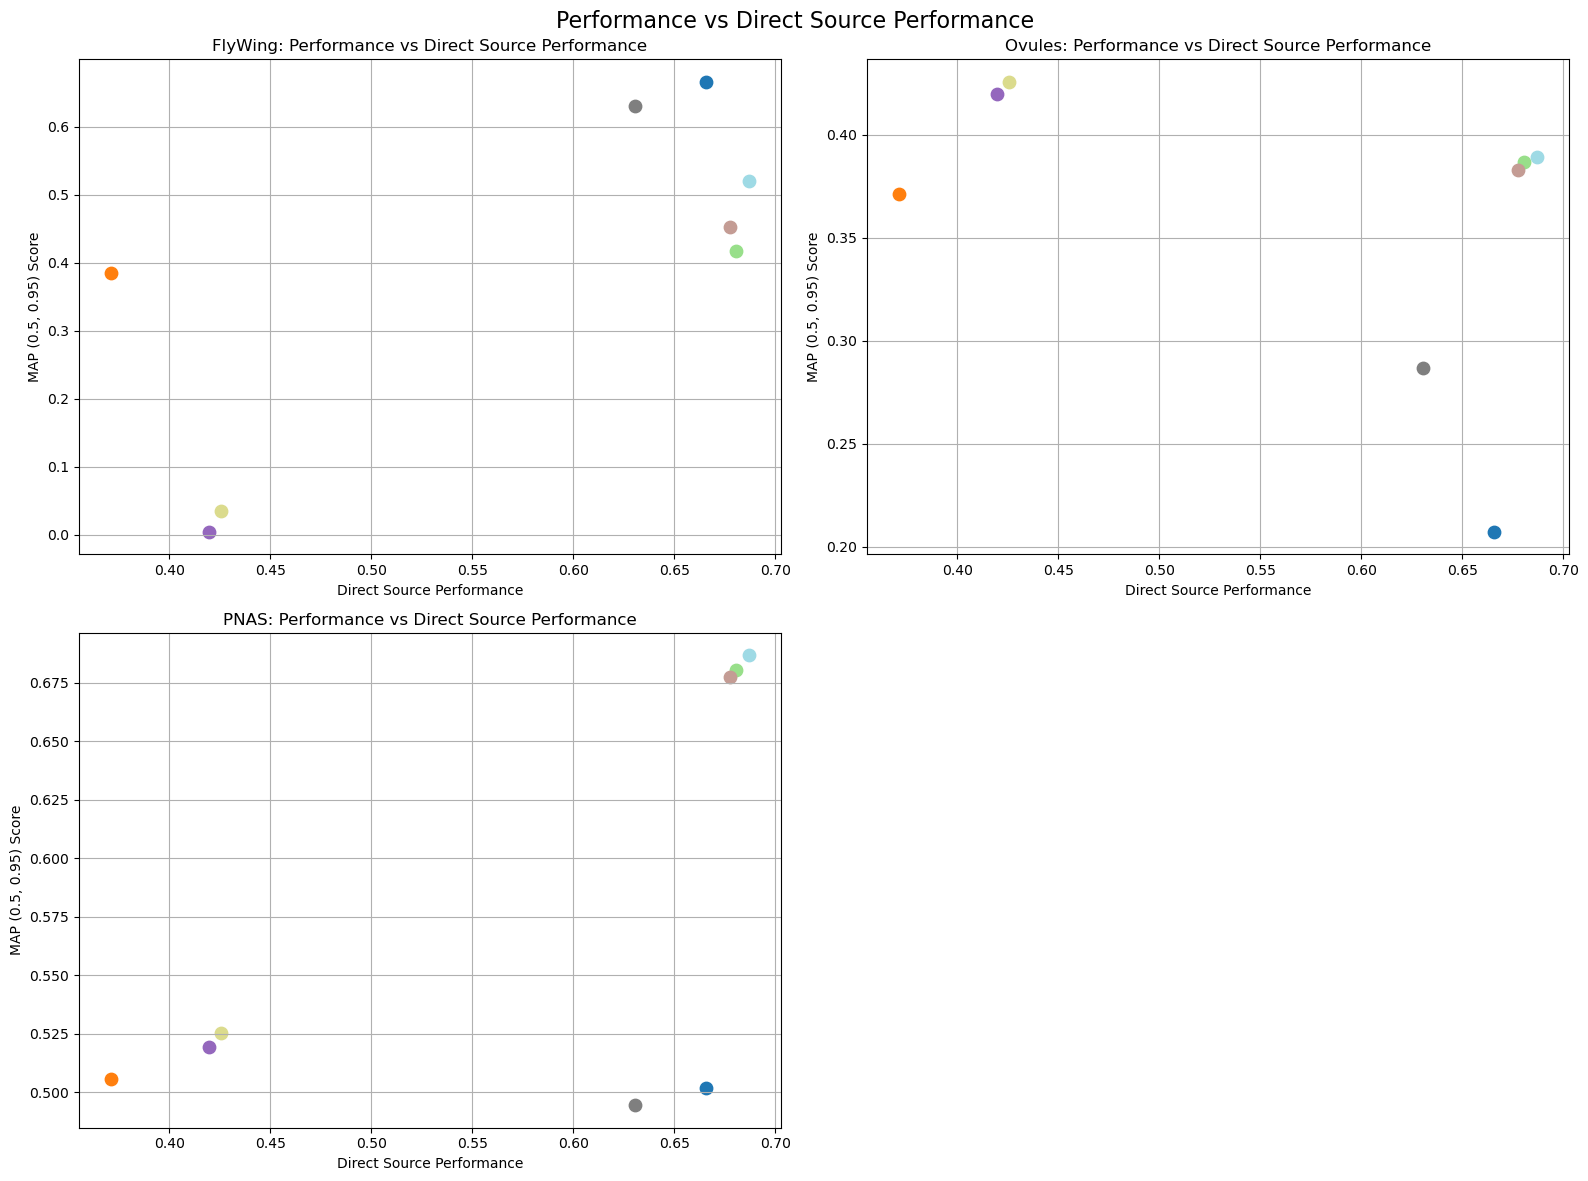

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.36     0.26   0.55        0.16  0.74     0.04
     Ovules   0.07     0.93  -0.02        1.00 -0.43     0.29
     PNAS     0.57     0.06   0.64        0.10  0.61     0.11
        KT_avg    KT_std  SR_avg    SR_std    PR_avg    PR_std
Task                                                          
Mito  0.333333  0.251064    0.39  0.357911  0.306667  0.641275


In [14]:
transfer_score_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/direct_source_performance_score_as_transfer_metric.json"
selected_augmentations = ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"]

plot_performance_vs_transfer_metric_multi_target(
    performance_scores=performance_scores,
        transfer_scores=per_target_source_performance,
        transfer_metric=f"Direct Source Performance",
        invert_transfer_metric=False,
        finetuned=False,
        performance_metric_key="MAP (0.5, 0.95)",
    )
KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
    targets=targets,
    transfer_metric_per_target=per_target_source_performance,
    performance_per_target=performance_scores,
    invert_transfer_metric=False,
)
cells_correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
print(cells_correlation_df)
df_cells_avg = avg_correlation_table(cells_correlation_df)
print(df_cells_avg)